# 10 – Provedor de Propriedades para CFD & Cinética Química

Solvers de Dinâmica dos Fluidos Computacional (CFD) e de cinética química
precisam avaliar propriedades termoquímicas **milhões de vezes** — uma vez por
célula por passo de tempo. Chamar a API completa do `pyglenn` (consulta SQL +
avaliação polinomial) a cada iteração é um desperdício; uma abordagem melhor é
**pré-carregar** os coeficientes em memória e usar laços de avaliação
especialmente otimizados.

Este notebook demonstra:

1. **Tabelas de propriedades em lote** — DataFrames do pandas com $C_p(T)$,
   $H(T)$, $S(T)$ em uma grade de temperaturas para qualquer conjunto de
   espécies
2. **Provedor de coeficientes em cache** — pré-busca dos coeficientes NASA em
   arrays NumPy para avaliação vetorizada em memória
3. **Benchmark** — provedor em cache vs. chamada bruta da API
4. **Integração de EDOs** — acoplando `pyglenn` com `scipy.integrate.solve_ivp`
   para o balanço de energia de um PFR (reator de fluxo pistonado) não
   isotérmico

Todas as medições de tempo são ilustrativas; os valores absolutos dependem da
máquina.

In [1]:
from pyglenn import ThermochemicalCalculator, R

print("Universal gas constant R =", R, "J/(mol.K)")


Constante universal dos gases R = 8.314462618 J/(mol.K)


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

import time
from scipy.integrate import solve_ivp

## 1. Tabelas de propriedades em lote

Gerar uma tabela de $C_p(T)$ para várias espécies em uma grade de temperaturas
compartilhada é simples. Esta é a estratégia "offline" mais simples: pré-calcule
uma vez, consulte rapidamente durante a simulação.

In [3]:
def batch_properties(calc, species_names, T_grid):
    """Retorna DataFrame com Cp [J/mol·K], H [kJ/mol], S [J/mol·K].

    Linhas = temperaturas, colunas = MultiIndex (propriedade, espécie).
    """
    ids = {name: calc.get_available_species(name, exact_match=True)[0]["id"] for name in species_names}
    records = []
    for T in T_grid:
        row = {"T": T}
        for name, sid in ids.items():
            p = calc.calculate_properties(sid, T)
            row[(name, "Cp")] = p["cp"]
            row[(name, "H")]  = p["h_relative"] / 1000
            row[(name, "S")]  = p["s"]
        records.append(row)

    df = pd.DataFrame(records).set_index("T")
    df.columns = pd.MultiIndex.from_tuples(df.columns, names=["espécie", "propriedade"])
    return df

# Exemplo: espécies relevantes para combustão, 300–3000 K
species_list = ["CH4", "O2", "N2", "CO2", "H2O", "CO", "H2"]
T_grid = np.linspace(300, 3000, 28)

with ThermochemicalCalculator() as calc:
    tbl = batch_properties(calc, species_list, T_grid)

print("Dimensão:", tbl.shape)
print()
# Mostra Cp em algumas temperaturas
print("Cp [J/(mol·K)] em temperaturas selecionadas:")
print(tbl.xs("Cp", axis=1, level="propriedade").round(1).head(8))


Dimensão: (28, 21)

Cp [J/(mol·K)] em temperaturas selecionadas:
espécie      CH4     O2     N2    CO2    H2O     CO     H2
T                                                         
300.000   35.800 29.400 29.100 37.200 33.600 29.100 28.800
400.000   40.600 30.100 29.200 41.300 34.300 29.300 29.200
500.000   46.600 31.100 29.600 44.600 35.200 29.800 29.300
600.000   52.700 32.100 30.100 47.300 36.300 30.400 29.300
700.000   58.500 33.000 30.800 49.600 37.500 31.200 29.400
800.000   64.000 33.700 31.400 51.400 38.700 31.900 29.600
900.000   69.100 34.400 32.100 53.000 40.000 32.600 29.900
1,000.000 73.700 34.900 32.700 54.300 41.300 33.200 30.200


## 2. Provedor de coeficientes em cache

Para uso em produção com CFD/cinética, queremos avaliar $C_p(T)$, $H(T)$,
$S(T)$ **sem consultas SQL**. A estratégia:

1. Consultar o banco de dados **uma vez** para extrair os coeficientes de cada
   espécie para cada intervalo de temperatura.
2. Armazená-los em arrays NumPy (`coeffs[N_espécies, N_intervalos, 9]`) e um
   array complementar `intervals[N_espécies, N_intervalos, 2]`.
3. Em tempo de execução, buscar binariamente o intervalo e avaliar o polinômio
   diretamente.

Isso reduz uma chamada de ~50 µs (SQL + Python) para uma avaliação de ~1 µs em
NumPy puro.

In [4]:
class CachedPropertyProvider:
    """Pré-carrega coeficientes NASA para um conjunto de espécies em arrays NumPy.

    Uma vez construído, ``cp(idx_esp, T)`` / ``h(idx_esp, T)`` / ``s(idx_esp, T)``
    avaliam em microssegundos sem acesso ao banco de dados.
    """

    def __init__(self, calc, species_names):
        # Constrói lista de espécies e mapa de índices
        self.names = list(species_names)
        self.name_to_idx = {n: i for i, n in enumerate(self.names)}
        n_spec = len(self.names)

        # Determina o número máximo de intervalos entre as espécies
        species_data = [calc.db.get_species_data(calc.get_available_species(name, exact_match=True)[0]["id"])
                        for name in self.names]
        max_intervals = max(len(sd["intervals"]) for sd in species_data)

        # Aloca arrays; preenche com NaN as posições de intervalo não usadas
        self.coeffs = np.full((n_spec, max_intervals, 9), np.nan)
        self.intervals = np.full((n_spec, max_intervals, 2), np.nan)  # [Tmin, Tmax]
        self.n_intervals = np.zeros(n_spec, dtype=int)

        for i, sd in enumerate(species_data):
            n_int = len(sd["intervals"])
            self.n_intervals[i] = n_int
            for j, interval in enumerate(sd["intervals"]):
                c = interval["coefficients"]
                self.coeffs[i, j, :] = [c["a1"], c["a2"], c["a3"], c["a4"],
                                         c["a5"], c["a6"], c["a7"],
                                         c["b1"], c["b2"]]
                self.intervals[i, j, :] = [interval["temp_min"],
                                            interval["temp_max"]]

    def _find_interval(self, i, T):
        """Retorna o índice do intervalo para a espécie i na temperatura T."""
        for j in range(self.n_intervals[i]):
            if self.intervals[i, j, 0] <= T <= self.intervals[i, j, 1]:
                return j
        raise ValueError(f"T={T} fora da faixa para {self.names[i]}")

    def cp(self, i, T):
        """Cp(T) em J/(mol·K) para o índice de espécie i."""
        j = self._find_interval(i, T)
        a1, a2, a3, a4, a5, a6, a7 = self.coeffs[i, j, :7]
        cp_r = (a1/T**2 + a2/T + a3 + a4*T + a5*T**2 + a6*T**3 + a7*T**4)
        return cp_r * R

    def h(self, i, T):
        """H°(T) em J/mol para o índice de espécie i."""
        j = self._find_interval(i, T)
        a1, a2, a3, a4, a5, a6, a7, b1, b2 = self.coeffs[i, j, :]
        h_rt = (-a1/T**2 + a2*np.log(T)/T + a3 + a4*T/2 + a5*T**2/3
                + a6*T**3/4 + a7*T**4/5 + b1/T)
        return h_rt * R * T

    def s(self, i, T):
        """S°(T) em J/(mol·K) para o índice de espécie i."""
        j = self._find_interval(i, T)
        a1, a2, a3, a4, a5, a6, a7, b1, b2 = self.coeffs[i, j, :]
        s_r = (-a1/(2*T**2) - a2/T + a3*np.log(T) + a4*T + a5*T**2/2
               + a6*T**3/3 + a7*T**4/4 + b2)
        return s_r * R


# Constrói o provedor uma única vez
with ThermochemicalCalculator() as calc:
    provider = CachedPropertyProvider(calc, ["CH4", "O2", "N2", "CO2", "H2O"])

# Verificação pontual contra a API completa
with ThermochemicalCalculator() as calc:
    for name in ["CH4", "CO2", "H2O"]:
        i = provider.name_to_idx[name]
        api = calc.calculate_properties(calc.get_available_species(name, exact_match=True)[0]["id"], 1500.0)
        print(f"{name:>4s}  Cp API={api['cp']:8.2f}  cache={provider.cp(i, 1500):8.2f}  "
              f"H API={api['h_relative']/1000:8.2f}  cache={provider.h(i, 1500)/1000:8.2f}  "
              f"S API={api['s']:8.3f}  cache={provider.s(i, 1500):8.3f}")


 CH4  Cp API=   90.87  cache=   90.87  H API=    5.59  cache=    5.59  S API= 281.749  cache= 281.749
 CO2  Cp API=   58.37  cache=   58.37  H API= -331.80  cache= -331.80  S API= 292.197  cache= 292.197
 H2O  Cp API=   47.32  cache=   47.32  H API= -193.62  cache= -193.62  S API= 250.657  cache= 250.657


## 3. Benchmark: cache vs. API bruta

Medimos a vazão para avaliações repetidas de $C_p(T)$. O provedor em cache deve
ser **10–50× mais rápido** porque evita consultas SQL, construção de dicionários
de resultado e marshalling em nível Python.

In [5]:
N = 5000
T_test = np.random.uniform(400, 2500, N)

species_bench = ["CH4", "O2", "N2", "CO2", "H2O"]

# Constrói provedor em cache
with ThermochemicalCalculator() as calc:
    prov = CachedPropertyProvider(calc, species_bench)

# --- Cache ---
t0 = time.perf_counter()
for k in range(N):
    _ = prov.cp(k % len(species_bench), T_test[k])
t_cached = time.perf_counter() - t0

# --- API bruta ---
with ThermochemicalCalculator() as calc:
    ids_bench = [calc.get_available_species(n, exact_match=True)[0]["id"] for n in species_bench]
    t0 = time.perf_counter()
    for k in range(N):
        _ = calc.calculate_properties(ids_bench[k % len(species_bench)],
                                       T_test[k])["cp"]
t_raw = time.perf_counter() - t0

print(f"{'Método':<12s} {'Tempo':>10s} {'por chamada':>12s} {'aceleração':>10s}")
print("-" * 46)
print(f"{'Cache':<12s} {t_cached:8.4f} s {t_cached/N*1e6:8.1f} µs {t_raw/t_cached:10.1f}x")
print(f"{'API bruta':<12s} {t_raw:8.4f} s {t_raw/N*1e6:8.1f} µs {'-':>10s}")


Método            Tempo  por chamada aceleração
----------------------------------------------
Cache          0.0213 s      4.3 µs        9.1x
API bruta      0.1927 s     38.5 µs          -


## 4. Integração de EDO: balanço de energia de PFR não isotérmico

Considere um reator de fluxo pistonado (PFR) onde uma reação exotérmica de
primeira ordem

$$\mathrm{A} \rightarrow \mathrm{B}, \quad r = k(T)\,C_A, \quad
k(T) = A \exp(-E_a/RT)$$

libera calor $\Delta H_\mathrm{rxn} < 0$. O balanço de energia se acopla ao
balanço de massa através de $C_p(T)$:

$$
\begin{aligned}
\frac{dC_A}{dt} &= -k(T)\,C_A \\[4pt]
\frac{dT}{dt}   &= -\frac{\Delta H_\mathrm{rxn}}{\rho\,C_p(T)}\,
                   \frac{dC_A}{dt}
\end{aligned}
$$

Usamos o `pyglenn` para fornecer o $C_p(T)$ *real* da mistura gasosa (modelada
como N₂, o gás de arraste) via o provedor em cache, e integramos com
`scipy.solve_ivp`.

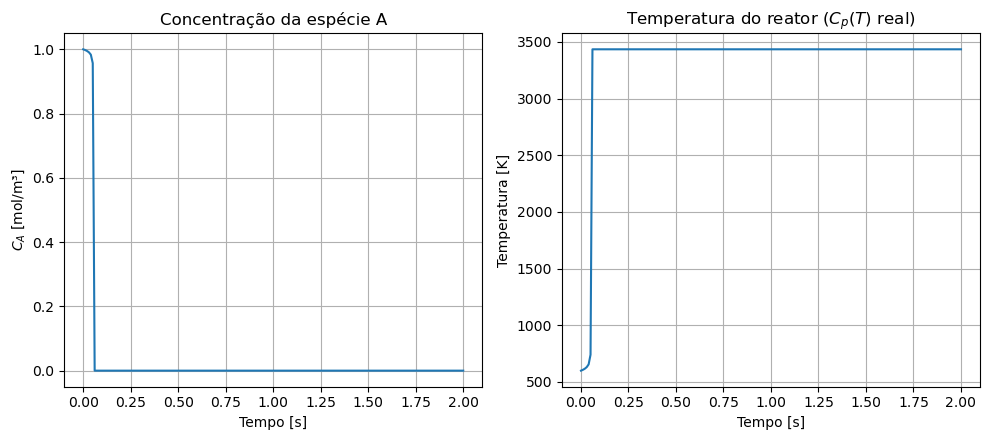

Conversão final: 100.0%
Temperatura final: 3435.4 K
Elevação de temperatura: 2835.4 K


In [6]:
# Parâmetros da reação (ilustrativos)
A_pre = 1e8           # 1/s
Ea = 100e3            # J/mol
dH_rxn = -100e3       # J/mol (exotérmica)
rho = 1.0             # mol/m³ (assumido constante, diluído em N2)

# Condições iniciais
CA0 = 1.0             # mol/m³
T0 = 600.0            # K

# Pré-carrega coeficientes do N2
with ThermochemicalCalculator() as calc:
    prov_ode = CachedPropertyProvider(calc, ["N2"])
i_N2 = prov_ode.name_to_idx["N2"]

def pfr_ode(t, y):
    """y = [CA, T]."""
    CA, T = y
    k = A_pre * np.exp(-Ea / (R * T))
    dCA_dt = -k * CA
    # Balanço de energia: dT/dt = (-dH_rxn / (rho * Cp(T))) * (-dCA_dt)
    cp_val = prov_ode.cp(i_N2, T)        # J/(mol·K) — nota: por mol de N2
    dT_dt = (-dH_rxn / (rho * cp_val)) * (-dCA_dt)
    return [dCA_dt, dT_dt]

# Integra por 2 segundos
t_span = (0, 2.0)
t_eval = np.linspace(0, 2, 200)
sol = solve_ivp(pfr_ode, t_span, [CA0, T0], t_eval=t_eval,
                method="RK45", rtol=1e-8, atol=1e-10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

ax1.plot(sol.t, sol.y[0])
ax1.set_xlabel("Tempo [s]")
ax1.set_ylabel("$C_A$ [mol/m³]")
ax1.set_title("Concentração da espécie A")

ax2.plot(sol.t, sol.y[1])
ax2.set_xlabel("Tempo [s]")
ax2.set_ylabel("Temperatura [K]")
ax2.set_title("Temperatura do reator ($C_p(T)$ real)")

plt.tight_layout()
plt.show()

print(f"Conversão final: {(1 - sol.y[0,-1]/CA0)*100:.1f}%")
print(f"Temperatura final: {sol.y[1,-1]:.1f} K")
print(f"Elevação de temperatura: {sol.y[1,-1] - T0:.1f} K")


## 5. Sensibilidade ao modelo de capacidade calorífica

Para destacar por que o $C_p(T)$ real importa, reexecutamos o PFR com uma
aproximação de $C_p$ constante (usando o valor do N₂ a 600 K) e comparamos as
trajetórias de temperatura.

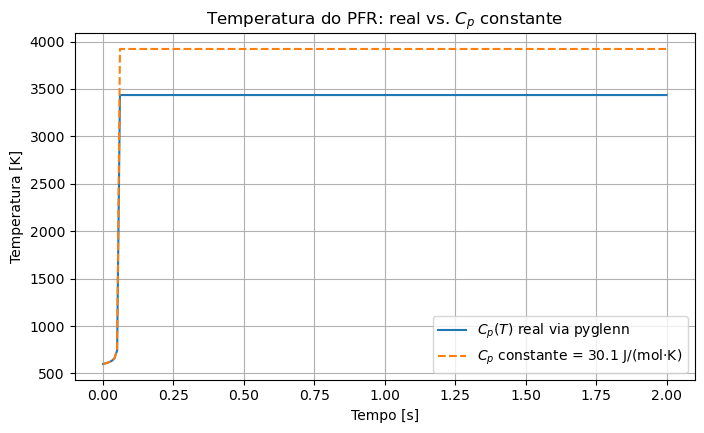

Elevação de temperatura (Cp real):    2835.4 K
Elevação de temperatura (Cp const):   3321.3 K
Diferença relativa:                   17.1%


In [7]:
# Aproximação com Cp constante
cp_const = prov_ode.cp(i_N2, 600.0)  # congela na T de entrada

def pfr_const_cp(t, y):
    CA, T = y
    k = A_pre * np.exp(-Ea / (R * T))
    dCA_dt = -k * CA
    dT_dt = (-dH_rxn / (rho * cp_const)) * (-dCA_dt)
    return [dCA_dt, dT_dt]

sol_const = solve_ivp(pfr_const_cp, t_span, [CA0, T0], t_eval=t_eval,
                      method="RK45", rtol=1e-8, atol=1e-10)

fig, ax = plt.subplots()
ax.plot(sol.t, sol.y[1], label="$C_p(T)$ real via pyglenn")
ax.plot(sol_const.t, sol_const.y[1], "--", label=f"$C_p$ constante = {cp_const:.1f} J/(mol·K)")
ax.set_xlabel("Tempo [s]")
ax.set_ylabel("Temperatura [K]")
ax.set_title("Temperatura do PFR: real vs. $C_p$ constante")
ax.legend()
plt.show()

dT_real = sol.y[1, -1] - T0
dT_const = sol_const.y[1, -1] - T0
print(f"Elevação de temperatura (Cp real):    {dT_real:.1f} K")
print(f"Elevação de temperatura (Cp const):   {dT_const:.1f} K")
print(f"Diferença relativa:                   {abs(dT_real - dT_const) / dT_real * 100:.1f}%")


## 6. Construindo uma tabela de interpolação para consultas CFD ultra-rápidas

Para o caminho mais rápido possível — necessário quando $C_p$ é exigido em
milhões de pontos de malha — pré-calcule uma tabela densa em $T$ e use
interpolação linear. Isto mede o custo adicional da interpolação.

In [8]:
# Constrói uma tabela densa de Cp(T) para N2
T_dense = np.linspace(300, 3000, 2000)
with ThermochemicalCalculator() as calc:
    cp_table = np.array([calc.calculate_properties(calc.get_available_species("N2", exact_match=True)[0]["id"], T)["cp"]
                         for T in T_dense])

# Consulta por interpolação
N_lookup = 100000
T_rand = np.random.uniform(300, 3000, N_lookup)

t0 = time.perf_counter()
cp_interp = np.interp(T_rand, T_dense, cp_table)
t_interp = time.perf_counter() - t0

# Provedor em cache
with ThermochemicalCalculator() as calc:
    prov_lookup = CachedPropertyProvider(calc, ["N2"])
iN2 = prov_lookup.name_to_idx["N2"]

t0 = time.perf_counter()
cp_cached = np.array([prov_lookup.cp(iN2, T) for T in T_rand])
t_cached = time.perf_counter() - t0

print(f"{'Método':<20s} {'Tempo':>10s} {'por chamada':>12s} {'aceleração':>10s}")
print("-" * 52)
print(f"{'np.interp (tabela)':<20s} {t_interp:8.4f} s {t_interp/N_lookup*1e6:8.1f} µs {t_cached/t_interp:10.1f}x")
print(f"{'Provedor em cache':<20s} {t_cached:8.4f} s {t_cached/N_lookup*1e6:8.1f} µs {'-':>10s}")

print(f"\nErro máximo de interpolação: {abs(cp_interp - cp_cached).max():.4f} J/(mol·K)")


Método                    Tempo  por chamada aceleração
----------------------------------------------------
np.interp (tabela)     0.0046 s      0.0 µs       47.8x
Provedor em cache      0.2177 s      2.2 µs          -

Erro máximo de interpolação: 0.0000 J/(mol·K)


## Resumo

| Estratégia | Vazão | Custo de setup | Memória | Ideal para |
|---|---|---|---|---|
| API bruta do `pyglenn` | ~50 µs/chamada | Nenhum | Mínima | Trabalho interativo |
| Provedor de coeficientes em cache | ~1–5 µs/chamada | Varredura única do BD | ~kB | Solvers de EDO / cinética |
| Tabela de interpolação pré-calculada | ~0,1 µs/chamada | Avaliação única em grade | ~kB–MB | CFD em produção |

- O **provedor de coeficientes em cache** elimina o custo de SQL mantendo a
  precisão polinomial completa — ideal para integração de EDOs.
- **Tabelas de interpolação** são a opção mais rápida para CFD em larga escala,
  mas introduzem um erro de discretização controlável.
- O `pyglenn` integra-se perfeitamente com `scipy.integrate.solve_ivp`: basta
  passar uma chamada `CachedPropertyProvider.cp(T)` na função do lado direito.

Isso conclui a série de dez notebooks. As ferramentas e padrões apresentados
aqui cobrem todo o espectro, da exploração interativa (notebooks 01–04) à
combustão aplicada (05–07) e equilíbrio (08), passando pela análise de ciclos
(09) e provisão de propriedades de alto desempenho (10).